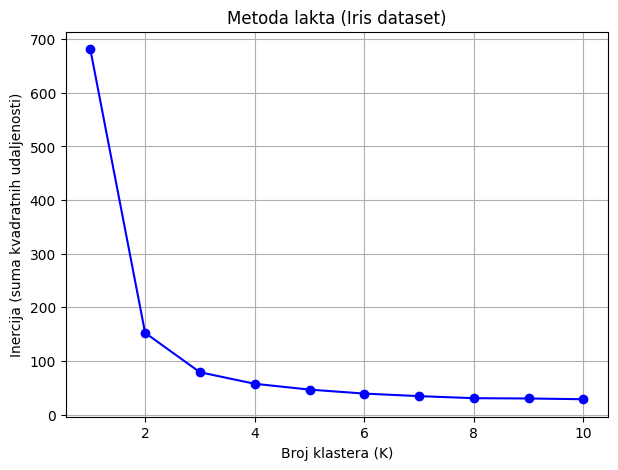

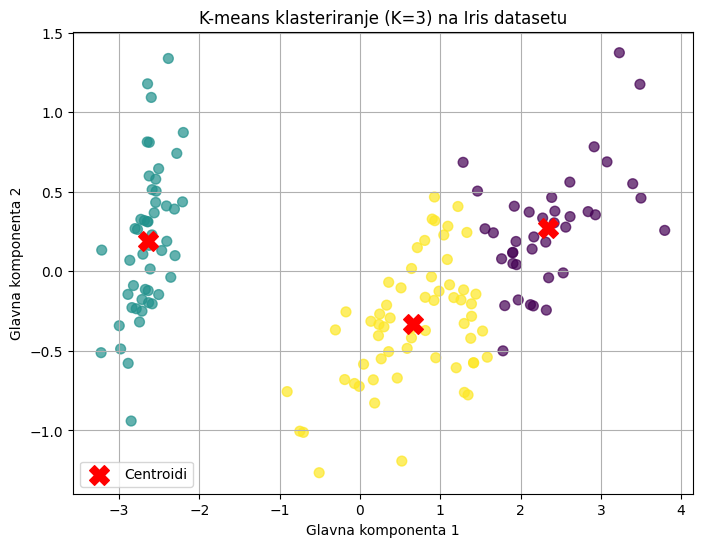


🔹 Tablica usporedbe (Confusion Matrix):
           Klaster 0  Klaster 1  Klaster 2
Stvarna 0          0         50          0
Stvarna 1          3          0         47
Stvarna 2         36          0         14

🔹 Adjusted Rand Index (ARI): 0.716
🔹 Adjusted Mutual Information (AMI): 0.739


In [6]:
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import confusion_matrix, adjusted_rand_score, adjusted_mutual_info_score
import pandas as pd
import numpy as np

iris = load_iris()
X = iris.data
y_true = iris.target
inertia = []
K_values = range(1, 11)

for k in K_values:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(7, 5))
plt.plot(K_values, inertia, 'bo-')
plt.title("Metoda lakta (Iris dataset)")
plt.xlabel("Broj klastera (K)")
plt.ylabel("Inercija (suma kvadratnih udaljenosti)")
plt.grid(True)
plt.show()

optimal_k = 3

kmeans = KMeans(n_clusters=optimal_k, random_state=42)
labels = kmeans.fit_predict(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, label='Centroidi')
plt.title(f"K-means klasteriranje (K={optimal_k}) na Iris datasetu")
plt.xlabel("Glavna komponenta 1")
plt.ylabel("Glavna komponenta 2")
plt.legend()
plt.grid(True)
plt.show()
conf_mat = confusion_matrix(y_true, labels)
conf_df = pd.DataFrame(conf_mat,
                       index=[f"Stvarna {i}" for i in np.unique(y_true)],
                       columns=[f"Klaster {i}" for i in np.unique(labels)])

print("\n🔹 Tablica usporedbe (Confusion Matrix):")
print(conf_df)
ari = adjusted_rand_score(y_true, labels)
ami = adjusted_mutual_info_score(y_true, labels)
print(f"\n🔹 Adjusted Rand Index (ARI): {ari:.3f}")
print(f"🔹 Adjusted Mutual Information (AMI): {ami:.3f}")
